In [1]:
from numpy import mean
from numpy import std
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score
from prettytable import PrettyTable
import numpy as np
import matplotlib.pyplot as plt

# Load your data from the Excel sheet
dataset = pd.read_excel('BBDM Project.xlsx')

# Assuming your target variable is named 'RMC'
X = data.drop('RMC', axis=1)
y = data['RMC']

# Convert categorical target variable to numerical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
# get a list of models to evaluate
def get_models():
    models = dict()
    models['LR'] = LogisticRegression(C=10, dual=False, max_iter=100, multi_class='auto', penalty='l2', solver='sag', tol=0.01)
    models['SVM'] = SVC(C=29.37, kernel='rbf', gamma='scale', probability=True)
    models['DT'] = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=9, min_samples_split=2)
    models['RF'] = RandomForestClassifier(max_depth=10, max_features='auto', min_samples_leaf=2, min_samples_split=10, n_estimators=50)
    models['KNN'] = KNeighborsClassifier(n_neighbors=36, weights='distance', algorithm='auto', p=1)
    models['XGBoost'] = XGBClassifier(colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=7, n_estimators=50, subsample=0.8)
    models['Bagging'] = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, max_samples=0.7, max_features=1.0, bootstrap=True, bootstrap_features=True)
    return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    return scores

# Define the base models
def get_base_models():
    models = dict()
    models['LR'] = LogisticRegression(C=10, dual=False, max_iter=100, multi_class='auto', penalty='l2', solver='sag', tol=0.01)
    models['SVM'] = SVC(C=40, kernel='rbf', gamma='scale', probability=True)
    models['DT'] = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=9, min_samples_split=2)
    models['RF'] = RandomForestClassifier(max_depth=10, max_features='auto', min_samples_leaf=2, min_samples_split=10, n_estimators=50)
    models['KNN'] = KNeighborsClassifier(n_neighbors=36, weights='distance', algorithm='auto', p=1)
    models['XGBoost'] = XGBClassifier(colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=7, n_estimators=50, subsample=0.8)
    models['Bagging'] = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, max_samples=0.7, max_features=1.0, bootstrap=True, bootstrap_features=True)
    return models

# Define the meta-models
def get_meta_models():
    models = dict()
    models['LR'] = LogisticRegression(C=10, dual=False, max_iter=100, multi_class='auto', penalty='l2', solver='sag', tol=0.01)
    models['SVM'] = SVC(C=40, kernel='rbf', gamma='scale', probability=True)
    models['DT'] = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=9, min_samples_split=2)
    models['RF'] = RandomForestClassifier(max_depth=10, max_features='auto', min_samples_leaf=2, min_samples_split=10, n_estimators=50)
    models['KNN'] = KNeighborsClassifier(n_neighbors=36, weights='distance', algorithm='auto', p=1)
    models['XGBoost'] = XGBClassifier(colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=7, n_estimators=50, subsample=0.8)
    models['Bagging'] = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, max_samples=0.7, max_features=1.0, bootstrap=True, bootstrap_features=True)
    return models

# Combine base models and meta models
base_models = get_base_models()
meta_models = get_meta_models()
all_models = {**base_models, **meta_models}

# Define the stacking classifier
stacking = StackingClassifier(estimators=list(base_models.items()), final_estimator=None)

# Define the grid search parameters
params = {'final_estimator': list(meta_models.values())}
# Perform the grid search
grid = GridSearchCV(estimator=stacking, param_grid=params, cv=10, scoring='accuracy')
grid_result = grid.fit(X_train, y_train)


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

...

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

In [2]:
# Print the results for all meta-models
for params, mean_score, std_score in zip(grid_result.cv_results_['params'], grid_result.cv_results_['mean_test_score'], grid_result.cv_results_['std_test_score']):
    meta_model_name = params['final_estimator'].__class__.__name__
    print("Meta-model: %s, Mean Accuracy: %f, Standard Deviation: %f" % (meta_model_name, mean_score, std_score))

Meta-model: LogisticRegression, Mean Accuracy: 0.851897, Standard Deviation: 0.015075
Meta-model: SVC, Mean Accuracy: 0.852623, Standard Deviation: 0.017374
Meta-model: DecisionTreeClassifier, Mean Accuracy: 0.837723, Standard Deviation: 0.015742
Meta-model: RandomForestClassifier, Mean Accuracy: 0.852259, Standard Deviation: 0.018039
Meta-model: KNeighborsClassifier, Mean Accuracy: 0.850442, Standard Deviation: 0.021896
Meta-model: XGBClassifier, Mean Accuracy: 0.852441, Standard Deviation: 0.018126
Meta-model: BaggingClassifier, Mean Accuracy: 0.847535, Standard Deviation: 0.018986


In [3]:
# Print the best stacking model
print("Best stacking model: %s, Mean Accuracy: %f, Standard Deviation: %f" % (grid_result.best_estimator_.final_estimator, grid_result.best_score_, grid_result.cv_results_['std_test_score'][grid_result.best_index_]))

Best stacking model: SVC(C=40, probability=True), Mean Accuracy: 0.852623, Standard Deviation: 0.017374


In [4]:
# Assuming grid_result is the result of your grid search
best_stacking_model = grid_result.best_estimator_

# Initialize dictionaries to store metrics for each meta-classifier
accuracy_dict = {}
precision_dict = {}
recall_dict = {}
f1_dict = {}
# Initialize list to store accuracy scores for each meta-classifier
accuracy_scores_list = []
# Iterate through all meta-models
for name, meta_model in meta_models.items():
    # Fit the stacking model with the current meta-classifier
    stacking_model = StackingClassifier(estimators=list(base_models.items()), final_estimator=meta_model)
    stacking_model.fit(X_train, y_train)

    # Cross-validate accuracy
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    accuracy_scores = cross_val_score(stacking_model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
    accuracy_dict[name] = accuracy_scores.mean()

    # Make predictions on the test set
    y_pred = stacking_model.predict(X_test)

    # Calculate precision, recall, and f1-score
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    precision_dict[name] = precision
    recall_dict[name] = recall
    f1_dict[name] = f1

# Create a PrettyTable
table = PrettyTable()
table.field_names = ["Meta-Classifier", "Accuracy", "Precision", "Recall", "F1-Score"]

# Iterate through all meta-classifiers
for name in meta_models.keys():
    table.add_row([name, f"{accuracy_dict[name]:.4f}", f"{precision_dict[name]:.4f}", f"{recall_dict[name]:.4f}", f"{f1_dict[name]:.4f}"])

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

In [5]:
# Print the table
print(table)

+-----------------+----------+-----------+--------+----------+
| Meta-Classifier | Accuracy | Precision | Recall | F1-Score |
+-----------------+----------+-----------+--------+----------+
|        LR       |  0.8546  |   0.8933  | 0.8917 |  0.8877  |
|       SVM       |  0.8555  |   0.9070  | 0.9055 |  0.9022  |
|        DT       |  0.8401  |   0.8713  | 0.8735 |  0.8717  |
|        RF       |  0.8524  |   0.9043  | 0.9026 |  0.8994  |
|       KNN       |  0.8494  |   0.9089  | 0.9077 |  0.9048  |
|     XGBoost     |  0.8532  |   0.9000  | 0.8990 |  0.8956  |
|     Bagging     |  0.8488  |   0.9032  | 0.9012 |  0.8979  |
+-----------------+----------+-----------+--------+----------+


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

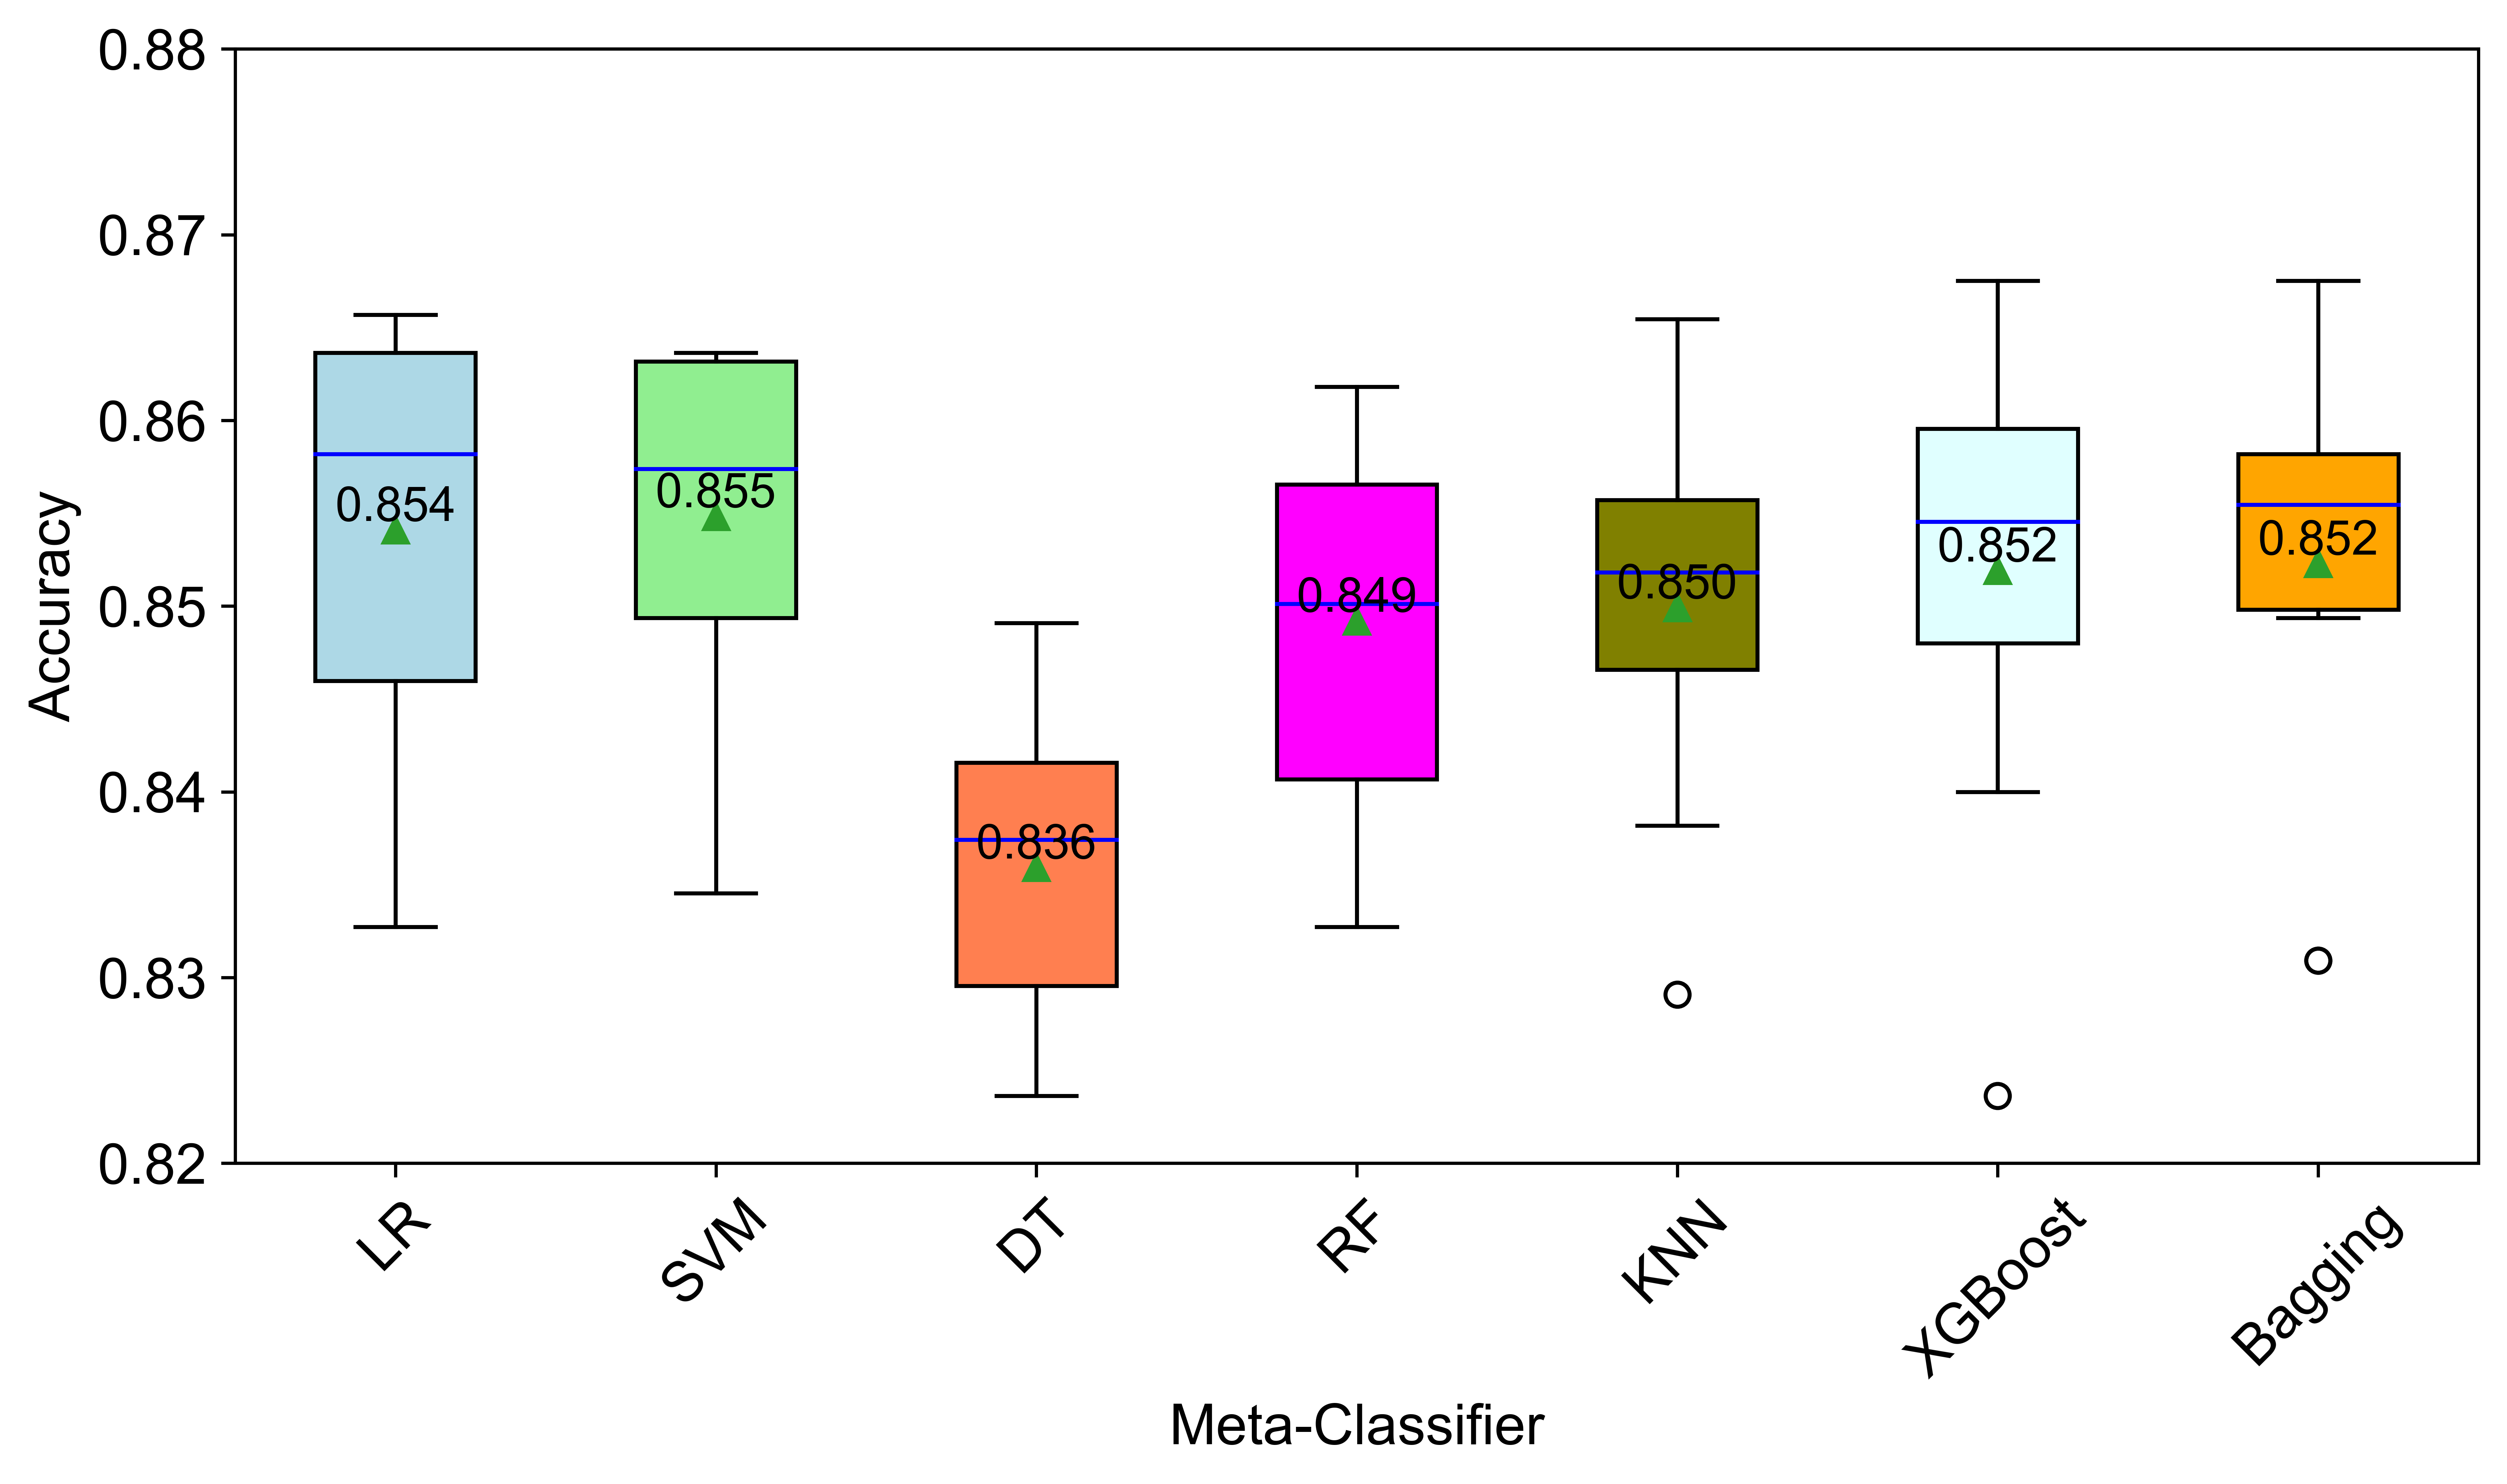

In [6]:
import matplotlib.pyplot as plt
import numpy as np
# Set font to Arial
plt.rcParams['font.family'] = 'Arial'
# Plot box-and-whisker plot for accuracy with customization
fig, ax = plt.subplots(figsize=(10, 5), dpi=800)  # Increased width for the figure

# Initialize an empty list to store accuracy scores for each meta-classifier
accuracy_scores_list = []

# Iterate through all meta-models
for name, meta_model in meta_models.items():
    # Fit the stacking model with the current meta-classifier
    stacking_model = StackingClassifier(estimators=list(base_models.items()), final_estimator=meta_model)
    stacking_model.fit(X_train, y_train)

    # Cross-validate accuracy
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    accuracy_scores = cross_val_score(stacking_model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
    
    # Append accuracy scores to the list
    accuracy_scores_list.append(accuracy_scores)



# Customize box plot appearance
box = ax.boxplot(accuracy_scores_list, labels=list(meta_models.keys()), showmeans=True, patch_artist=True, medianprops={'color': 'blue'})

# Set facecolor for boxes
for patch, color in zip(box['boxes'], ['lightblue', 'lightgreen', 'coral', 'magenta', 'olive','lightcyan','orange']):
    patch.set_facecolor(color)

ax.set_title('', fontsize=14)
ax.set_xlabel('Meta-Classifier', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)

# Set text size
ax.tick_params(axis='x', which='major', labelsize=14, rotation=45)  # x-axis
ax.tick_params(axis='y', which='major', labelsize=14)  # y-axis

# Set y-axis limits
ax.set_ylim(0.82, 0.88)

# Add mean values inside the boxplot
for i, mean_val in enumerate([np.mean(scores) for scores in accuracy_scores_list]):
    ax.text(i + 1, mean_val, f'{mean_val:.3f}', ha='center', va='bottom', color='black', fontsize=12, rotation=0)

plt.show()


In [7]:
# Show the plot
plt.show()

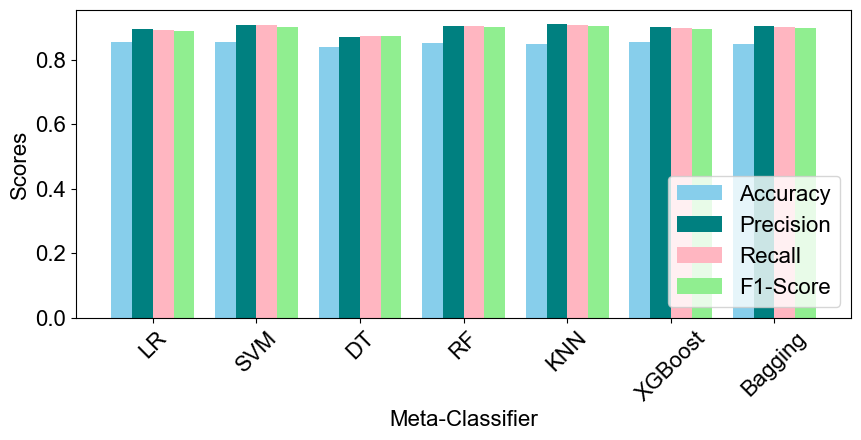

In [8]:
# Plot bar graph
labels = list(meta_models.keys())
accuracy_values = list(accuracy_dict.values())
precision_values = list(precision_dict.values())
recall_values = list(recall_dict.values())
f1_values = list(f1_dict.values())

bar_width = 0.2
index = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(index, accuracy_values, bar_width, label='Accuracy', color='skyblue')
rects2 = ax.bar(index + bar_width, precision_values, bar_width, label='Precision', color='teal')
rects3 = ax.bar(index + 2 * bar_width, recall_values, bar_width, label='Recall', color='lightpink')
rects4 = ax.bar(index + 3 * bar_width, f1_values, bar_width, label='F1-Score', color='lightgreen')

ax.set_xlabel('Meta-Classifier', fontsize=16)
ax.set_ylabel('Scores', fontsize=16)
ax.set_title('', fontsize=16) # you select title as "Performance Metrics for Meta-Classifiers"
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(labels,ha='center')
# Set text size individually for each axis
ax.tick_params(axis='x', labelsize=16, rotation=45)  # x-axis
ax.tick_params(axis='y',  labelsize=16)  # y-axis
ax.legend(loc='lower right', fontsize=16)

plt.show()